# Road Damage Detection — 00. Dataset Setup and Audit

Run this notebook once before training YOLOv8s, YOLO11s, and YOLO26s.

This updated workflow:

1. mounts Google Drive;
2. reuses the dataset already downloaded in Colab or downloads it securely from Roboflow;
3. preserves the original source dataset;
4. converts polygon annotations into standard axis-aligned YOLO detection boxes;
5. validates only the converted object-detection dataset;
6. checks exact duplicate leakage across train, validation, and test;
7. creates class and bounding-box statistics;
8. displays annotated samples;
9. blocks training when critical problems remain;
10. persists the final processed dataset and audit reports in Google Drive.

> This notebook does not require a GPU. A CPU runtime is sufficient.

## Expected Roboflow project

The defaults below match your project:

- Workspace: `tarek-amr-7rdkn`
- Project: `road-damage-l1ju7-rhumc`
- Version: `1`
- Export format: `yolov8`

The standard YOLOv8 export is correct for this project.  
YOLOv8 Oriented Bounding Boxes should not be used.

In [1]:
%pip install -q         roboflow         ultralytics         pyyaml         pandas         matplotlib         pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 634.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.6 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import random
import shutil
import sys
from collections import Counter, defaultdict
from datetime import datetime, timezone
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import torch
import ultralytics
import yaml
from PIL import Image, ImageOps
from roboflow import Roboflow

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. That is fine for dataset setup and auditing.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cpu
Ultralytics: 8.4.92
CUDA available: False
No GPU detected. That is fine for dataset setup and auditing.


## 1. Mount Google Drive and define all shared paths

In [3]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/RoadDamageYOLO")

# Persistent source dataset. Never train from this directory.
PERSISTENT_SOURCE_DATASET_DIR = (
    PROJECT_ROOT / "data" / "road-damage-source-v1"
)

# Persistent processed object-detection dataset.
# All training and comparison notebooks must use this path.
PERSISTENT_DATASET_DIR = (
    PROJECT_ROOT / "data" / "road-damage-detection-bbox-v1"
)

# Temporary local Colab paths.
LOCAL_SOURCE_DATASET_DIR = Path("/content/road-damage-source-v1")
LOCAL_DATASET_DIR = Path("/content/road-damage-detection-bbox-v1")

REPORTS_ROOT = PROJECT_ROOT / "reports"
AUDIT_DIR = REPORTS_ROOT / "data_audit_bbox_v1"

for directory in [
    PROJECT_ROOT,
    PERSISTENT_SOURCE_DATASET_DIR.parent,
    REPORTS_ROOT,
    AUDIT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Persistent processed dataset:", PERSISTENT_DATASET_DIR)

Mounted at /content/drive
Project root: /content/drive/MyDrive/RoadDamageYOLO
Persistent processed dataset: /content/drive/MyDrive/RoadDamageYOLO/data/road-damage-detection-bbox-v1


## 2. Acquire or restore the original source dataset

In [4]:
WORKSPACE_ID = "tarek-amr-7rdkn"
PROJECT_ID = "road-damage-l1ju7-rhumc"
VERSION_NUMBER = 1
EXPORT_FORMAT = "yolov8"

source_local_ready = (
    LOCAL_SOURCE_DATASET_DIR.exists()
    and (LOCAL_SOURCE_DATASET_DIR / "data.yaml").exists()
)

source_drive_ready = (
    PERSISTENT_SOURCE_DATASET_DIR.exists()
    and (PERSISTENT_SOURCE_DATASET_DIR / "data.yaml").exists()
)

if source_local_ready:
    print("Using existing source dataset in Colab:", LOCAL_SOURCE_DATASET_DIR)

elif source_drive_ready:
    print("Restoring source dataset from Google Drive...")
    shutil.copytree(
        PERSISTENT_SOURCE_DATASET_DIR,
        LOCAL_SOURCE_DATASET_DIR,
        dirs_exist_ok=True,
    )

else:
    api_key = getpass("Enter your NEW Roboflow private API key: ")
    rf = Roboflow(api_key=api_key)

    workspace = rf.workspace(WORKSPACE_ID)
    project = workspace.project(PROJECT_ID)

    versions = project.versions()
    print("Available versions:", versions)

    if not versions:
        raise RuntimeError(
            "No generated Roboflow dataset versions were found. "
            "Generate Version 1 first."
        )

    dataset = project.version(VERSION_NUMBER).download(
        model_format=EXPORT_FORMAT,
        location=str(LOCAL_SOURCE_DATASET_DIR),
    )

    print("Downloaded source dataset to:", dataset.location)

if not (LOCAL_SOURCE_DATASET_DIR / "data.yaml").exists():
    raise FileNotFoundError(
        f"Missing source data.yaml at "
        f"{LOCAL_SOURCE_DATASET_DIR / 'data.yaml'}"
    )

if not source_drive_ready:
    print("Persisting the original source dataset to Google Drive...")
    shutil.copytree(
        LOCAL_SOURCE_DATASET_DIR,
        PERSISTENT_SOURCE_DATASET_DIR,
        dirs_exist_ok=True,
    )

print("Source dataset ready:", LOCAL_SOURCE_DATASET_DIR)

Enter your NEW Roboflow private API key: ··········
loading Roboflow workspace...
loading Roboflow project...
Available versions: [<roboflow.core.version.Version object at 0x7e1898b3a6c0>]



Extracting Dataset Version Zip to /content/road-damage-source-v1 in yolov8:: 100%|██████████| 13519/13519 [00:11<00:00, 1140.04it/s]


Downloaded source dataset to: /content/road-damage-source-v1
Persisting the original source dataset to Google Drive...
Source dataset ready: /content/road-damage-source-v1


## 3. Convert polygons to standard YOLO detection boxes

Supported input rows:

**Existing detection box**

```text
class_id x_center y_center width height
```

**Segmentation polygon**

```text
class_id x1 y1 x2 y2 ... xn yn
```

Polygon rows are converted to the smallest enclosing axis-aligned rectangle.

The original source dataset remains unchanged.

In [5]:
FORCE_REBUILD_PROCESSED_DATASET = True

if LOCAL_DATASET_DIR.exists() and FORCE_REBUILD_PROCESSED_DATASET:
    shutil.rmtree(LOCAL_DATASET_DIR)

if not LOCAL_DATASET_DIR.exists():
    shutil.copytree(
        LOCAL_SOURCE_DATASET_DIR,
        LOCAL_DATASET_DIR,
    )

conversion_records = []
conversion_errors = []

split_names = ["train", "valid", "val", "test"]

for split_name in split_names:
    labels_dir = LOCAL_DATASET_DIR / split_name / "labels"

    if not labels_dir.exists():
        continue

    for label_path in sorted(labels_dir.glob("*.txt")):
        source_lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        converted_lines = []

        for line_number, raw_line in enumerate(source_lines, start=1):
            line = raw_line.strip()

            if not line:
                continue

            parts = line.split()

            try:
                class_id = int(float(parts[0]))
            except (ValueError, IndexError):
                conversion_errors.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "invalid_class_id",
                    "content": line,
                })
                continue

            # Standard YOLO detection annotation.
            if len(parts) == 5:
                try:
                    x_center, y_center, width, height = map(
                        float,
                        parts[1:],
                    )
                except ValueError:
                    conversion_errors.append({
                        "file": str(label_path),
                        "line": line_number,
                        "reason": "non_numeric_detection_box",
                        "content": line,
                    })
                    continue

                values = [x_center, y_center, width, height]
                if not all(np.isfinite(values)):
                    conversion_errors.append({
                        "file": str(label_path),
                        "line": line_number,
                        "reason": "non_finite_detection_box",
                        "content": line,
                    })
                    continue

                converted_lines.append(
                    f"{class_id} "
                    f"{x_center:.10f} "
                    f"{y_center:.10f} "
                    f"{width:.10f} "
                    f"{height:.10f}"
                )

                conversion_records.append({
                    "file": str(label_path),
                    "line": line_number,
                    "source_type": "bounding_box",
                    "class_id": class_id,
                })
                continue

            # Polygon requires at least three x,y points.
            coordinate_values = parts[1:]

            if (
                len(coordinate_values) < 6
                or len(coordinate_values) % 2 != 0
            ):
                conversion_errors.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "invalid_polygon_coordinate_count",
                    "value_count": len(parts),
                    "content": line,
                })
                continue

            try:
                coordinates = list(map(float, coordinate_values))
            except ValueError:
                conversion_errors.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "non_numeric_polygon",
                    "content": line,
                })
                continue

            if not all(np.isfinite(coordinates)):
                conversion_errors.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "non_finite_polygon",
                    "content": line,
                })
                continue

            x_values = np.clip(
                np.asarray(coordinates[0::2], dtype=float),
                0.0,
                1.0,
            )
            y_values = np.clip(
                np.asarray(coordinates[1::2], dtype=float),
                0.0,
                1.0,
            )

            x_min = float(x_values.min())
            x_max = float(x_values.max())
            y_min = float(y_values.min())
            y_max = float(y_values.max())

            width = x_max - x_min
            height = y_max - y_min

            if width <= 0 or height <= 0:
                conversion_errors.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "degenerate_polygon_box",
                    "content": line,
                })
                continue

            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2

            converted_lines.append(
                f"{class_id} "
                f"{x_center:.10f} "
                f"{y_center:.10f} "
                f"{width:.10f} "
                f"{height:.10f}"
            )

            conversion_records.append({
                "file": str(label_path),
                "line": line_number,
                "source_type": "polygon",
                "class_id": class_id,
                "polygon_points": len(x_values),
                "bbox_x_center": x_center,
                "bbox_y_center": y_center,
                "bbox_width": width,
                "bbox_height": height,
            })

        output_text = "\n".join(converted_lines)
        if output_text:
            output_text += "\n"

        label_path.write_text(
            output_text,
            encoding="utf-8",
        )

conversion_df = pd.DataFrame(conversion_records)
conversion_errors_df = pd.DataFrame(conversion_errors)

print("Converted annotation rows:", len(conversion_df))
print("Conversion errors:", len(conversion_errors_df))

if not conversion_df.empty:
    display(conversion_df["source_type"].value_counts())

if not conversion_errors_df.empty:
    display(conversion_errors_df.head(20))

Converted annotation rows: 20617
Conversion errors: 0


,count
source_type,
bounding_box,20532
polygon,85


## 4. Create the canonical object-detection YAML

In [6]:
source_yaml_path = LOCAL_DATASET_DIR / "data.yaml"

with source_yaml_path.open("r", encoding="utf-8") as file:
    source_config = yaml.safe_load(file)

names = source_config.get("names")
if not names:
    raise ValueError("No class names were found in the source data.yaml.")

validation_folder = (
    "valid"
    if (LOCAL_DATASET_DIR / "valid").exists()
    else "val"
)

canonical_config = {
    "path": str(LOCAL_DATASET_DIR.resolve()),
    "train": "train/images",
    "val": f"{validation_folder}/images",
    "test": "test/images",
    "names": names,
}

DATA_YAML = LOCAL_DATASET_DIR / "data_detection.yaml"

with DATA_YAML.open("w", encoding="utf-8") as file:
    yaml.safe_dump(
        canonical_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print(DATA_YAML.read_text())

path: /content/road-damage-detection-bbox-v1
train: train/images
val: valid/images
test: test/images
names:
- alligator
- block
- crack
- edge
- longitudinal
- pothole
- transverse



## 5. Strict validation of the processed detection dataset

In [7]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}

with DATA_YAML.open("r", encoding="utf-8") as file:
    dataset_config = yaml.safe_load(file)

raw_names = dataset_config["names"]

if isinstance(raw_names, dict):
    class_names = {
        int(key): str(value)
        for key, value in raw_names.items()
    }
else:
    class_names = {
        index: str(value)
        for index, value in enumerate(raw_names)
    }

SPLIT_DIRS = {
    "train": LOCAL_DATASET_DIR / "train",
    "val": LOCAL_DATASET_DIR / validation_folder,
    "test": LOCAL_DATASET_DIR / "test",
}

image_records = []
box_records = []
validation_errors = []
hash_entries = defaultdict(list)

def file_sha256(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

for split, split_dir in SPLIT_DIRS.items():
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    if not images_dir.exists():
        validation_errors.append({
            "split": split,
            "type": "missing_images_directory",
            "path": str(images_dir),
        })
        continue

    if not labels_dir.exists():
        validation_errors.append({
            "split": split,
            "type": "missing_labels_directory",
            "path": str(labels_dir),
        })
        continue

    image_paths = sorted(
        path
        for path in images_dir.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"

        image_valid = True
        width_px = None
        height_px = None

        try:
            with Image.open(image_path) as image:
                image = ImageOps.exif_transpose(image)
                image.load()
                width_px, height_px = image.size

            if width_px <= 0 or height_px <= 0:
                raise ValueError("Image has invalid dimensions.")

        except Exception as error:
            image_valid = False
            validation_errors.append({
                "split": split,
                "type": "corrupt_image",
                "path": str(image_path),
                "detail": repr(error),
            })

        try:
            digest = file_sha256(image_path)
            hash_entries[digest].append(
                (split, str(image_path))
            )
        except Exception as error:
            validation_errors.append({
                "split": split,
                "type": "hash_error",
                "path": str(image_path),
                "detail": repr(error),
            })

        object_count = 0
        label_exists = label_path.exists()

        if not label_exists:
            validation_errors.append({
                "split": split,
                "type": "missing_label_file",
                "path": str(label_path),
            })
        else:
            lines = [
                line.strip()
                for line in label_path.read_text(
                    encoding="utf-8"
                ).splitlines()
                if line.strip()
            ]

            for line_number, line in enumerate(lines, start=1):
                parts = line.split()

                if len(parts) != 5:
                    validation_errors.append({
                        "split": split,
                        "type": "invalid_field_count",
                        "path": str(label_path),
                        "line": line_number,
                        "value_count": len(parts),
                        "content": line,
                    })
                    continue

                try:
                    class_id = int(float(parts[0]))
                    x_center, y_center, width, height = map(
                        float,
                        parts[1:],
                    )
                except ValueError:
                    validation_errors.append({
                        "split": split,
                        "type": "non_numeric_label",
                        "path": str(label_path),
                        "line": line_number,
                        "content": line,
                    })
                    continue

                if class_id not in class_names:
                    validation_errors.append({
                        "split": split,
                        "type": "unknown_class_id",
                        "path": str(label_path),
                        "line": line_number,
                        "class_id": class_id,
                    })
                    continue

                values = [x_center, y_center, width, height]

                if not all(np.isfinite(values)):
                    validation_errors.append({
                        "split": split,
                        "type": "non_finite_box",
                        "path": str(label_path),
                        "line": line_number,
                    })
                    continue

                normalized_valid = (
                    0.0 <= x_center <= 1.0
                    and 0.0 <= y_center <= 1.0
                    and 0.0 < width <= 1.0
                    and 0.0 < height <= 1.0
                )

                x_min = x_center - width / 2
                y_min = y_center - height / 2
                x_max = x_center + width / 2
                y_max = y_center + height / 2

                inside_image = (
                    x_min >= -1e-6
                    and y_min >= -1e-6
                    and x_max <= 1.0 + 1e-6
                    and y_max <= 1.0 + 1e-6
                )

                if not normalized_valid or not inside_image:
                    validation_errors.append({
                        "split": split,
                        "type": "invalid_box",
                        "path": str(label_path),
                        "line": line_number,
                        "class_id": class_id,
                        "box": values,
                    })
                    continue

                object_count += 1

                box_records.append({
                    "split": split,
                    "image": str(image_path),
                    "class_id": class_id,
                    "class_name": class_names[class_id],
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": width,
                    "height": height,
                    "area": width * height,
                    "aspect_ratio": width / height,
                })

        image_records.append({
            "split": split,
            "image": str(image_path),
            "label": str(label_path),
            "image_valid": image_valid,
            "label_exists": label_exists,
            "width": width_px,
            "height": height_px,
            "objects": object_count,
        })

images_df = pd.DataFrame(image_records)
boxes_df = pd.DataFrame(box_records)
errors_df = pd.DataFrame(validation_errors)

cross_split_duplicate_rows = []

for digest, entries in hash_entries.items():
    splits = sorted({split for split, _ in entries})

    if len(splits) > 1:
        cross_split_duplicate_rows.append({
            "sha256": digest,
            "splits": ", ".join(splits),
            "count": len(entries),
            "files": " | ".join(
                path
                for _, path in entries
            ),
        })

duplicates_df = pd.DataFrame(
    cross_split_duplicate_rows
)

print("Classes:")
display(pd.Series(class_names, name="class_name"))

print("\nImage summary:")
display(
    images_df.groupby("split").agg(
        images=("image", "count"),
        valid_images=("image_valid", "sum"),
        images_with_labels=("label_exists", "sum"),
        objects=("objects", "sum"),
    )
)

print("\nValidation errors:", len(errors_df))
display(errors_df.head(20))

print(
    "\nExact duplicate groups crossing splits:",
    len(duplicates_df),
)
display(duplicates_df.head(20))

Classes:


,class_name
0,alligator
1,block
2,crack
3,edge
4,longitudinal
5,pothole
6,transverse



Image summary:


,images,valid_images,images_with_labels,objects
split,,,,
test,681,681,681,2004
train,4930,4930,4930,15025
val,1146,1146,1146,3588



Validation errors: 0


""



Exact duplicate groups crossing splits: 0


""


## 6. Training gate

In [8]:
critical_types = {
    "missing_images_directory",
    "missing_labels_directory",
    "corrupt_image",
    "invalid_field_count",
    "non_numeric_label",
    "unknown_class_id",
    "non_finite_box",
    "invalid_box",
}

critical_errors = (
    int(errors_df["type"].isin(critical_types).sum())
    if not errors_df.empty
    else 0
)

conversion_error_count = len(conversion_errors_df)
duplicate_group_count = len(duplicates_df)

gate_summary = {
    "conversion_errors": int(conversion_error_count),
    "critical_validation_errors": int(critical_errors),
    "all_validation_errors": int(len(errors_df)),
    "cross_split_exact_duplicate_groups": int(
        duplicate_group_count
    ),
    "processed_annotations": int(len(boxes_df)),
}

print(json.dumps(gate_summary, indent=2))

assert conversion_error_count == 0, (
    f"Training blocked: {conversion_error_count} "
    "annotation conversion errors remain."
)

assert critical_errors == 0, (
    f"Training blocked: {critical_errors} "
    "critical dataset validation errors remain."
)

assert duplicate_group_count == 0, (
    "Training blocked: exact duplicate images exist "
    "across dataset splits."
)

print("\nDataset passed the training gate.")

{
  "conversion_errors": 0,
  "critical_validation_errors": 0,
  "all_validation_errors": 0,
  "cross_split_exact_duplicate_groups": 0,
  "processed_annotations": 20617
}

Dataset passed the training gate.


## 7. Save machine-readable audit reports

In [9]:
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

conversion_df.to_csv(
    AUDIT_DIR / "conversion_records.csv",
    index=False,
)

conversion_errors_df.to_csv(
    AUDIT_DIR / "conversion_errors.csv",
    index=False,
)

images_df.to_csv(
    AUDIT_DIR / "images.csv",
    index=False,
)

boxes_df.to_csv(
    AUDIT_DIR / "boxes.csv",
    index=False,
)

errors_df.to_csv(
    AUDIT_DIR / "validation_errors.csv",
    index=False,
)

duplicates_df.to_csv(
    AUDIT_DIR / "cross_split_exact_duplicates.csv",
    index=False,
)

audit_summary = {
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "source_dataset_dir": str(
        LOCAL_SOURCE_DATASET_DIR
    ),
    "processed_dataset_dir": str(
        LOCAL_DATASET_DIR
    ),
    "dataset_yaml": str(DATA_YAML),
    "classes": class_names,
    "images_by_split": (
        images_df.groupby("split")
        .size()
        .astype(int)
        .to_dict()
    ),
    "objects_by_split": (
        images_df.groupby("split")["objects"]
        .sum()
        .astype(int)
        .to_dict()
    ),
    "conversion_counts": (
        conversion_df["source_type"]
        .value_counts()
        .astype(int)
        .to_dict()
        if not conversion_df.empty
        else {}
    ),
    **gate_summary,
}

(AUDIT_DIR / "summary.json").write_text(
    json.dumps(
        audit_summary,
        indent=2,
    ),
    encoding="utf-8",
)

print(json.dumps(audit_summary, indent=2))

{
  "created_at_utc": "2026-07-11T15:59:17.303188+00:00",
  "source_dataset_dir": "/content/road-damage-source-v1",
  "processed_dataset_dir": "/content/road-damage-detection-bbox-v1",
  "dataset_yaml": "/content/road-damage-detection-bbox-v1/data_detection.yaml",
  "classes": {
    "0": "alligator",
    "1": "block",
    "2": "crack",
    "3": "edge",
    "4": "longitudinal",
    "5": "pothole",
    "6": "transverse"
  },
  "images_by_split": {
    "test": 681,
    "train": 4930,
    "val": 1146
  },
  "objects_by_split": {
    "test": 2004,
    "train": 15025,
    "val": 3588
  },
  "conversion_counts": {
    "bounding_box": 20532,
    "polygon": 85
  },
  "conversion_errors": 0,
  "critical_validation_errors": 0,
  "all_validation_errors": 0,
  "cross_split_exact_duplicate_groups": 0,
  "processed_annotations": 20617
}


## 8. Class-distribution and bounding-box analysis

split,test,train,val,total
class_name,,,,
pothole,909,6074,1600,8583
alligator,577,4337,1001,5915
longitudinal,311,2008,548,2867
crack,93,1796,226,2115
transverse,67,484,126,677
block,47,305,86,438
edge,0,21,1,22


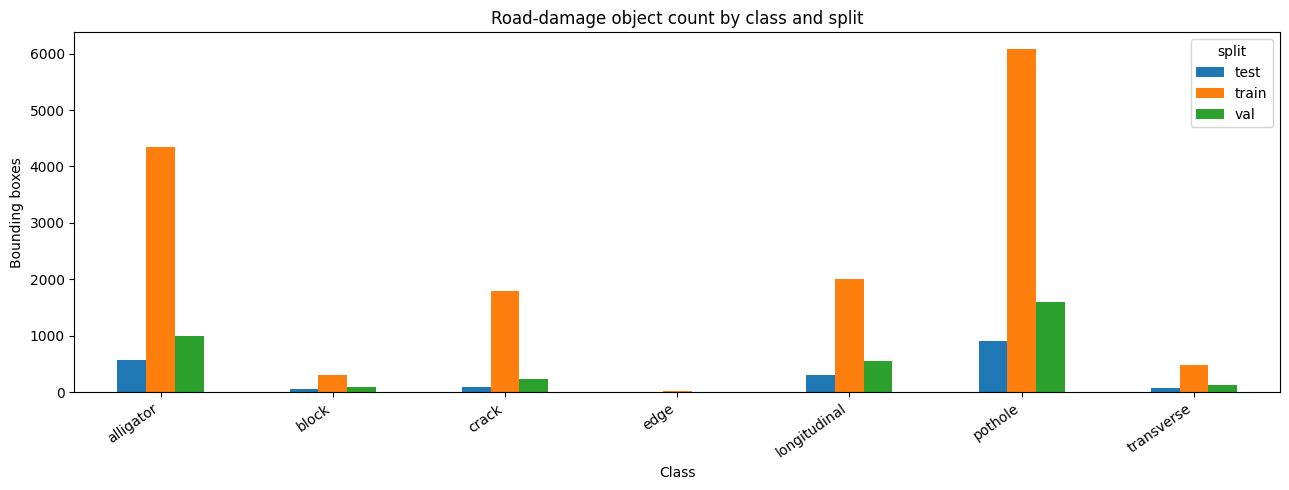

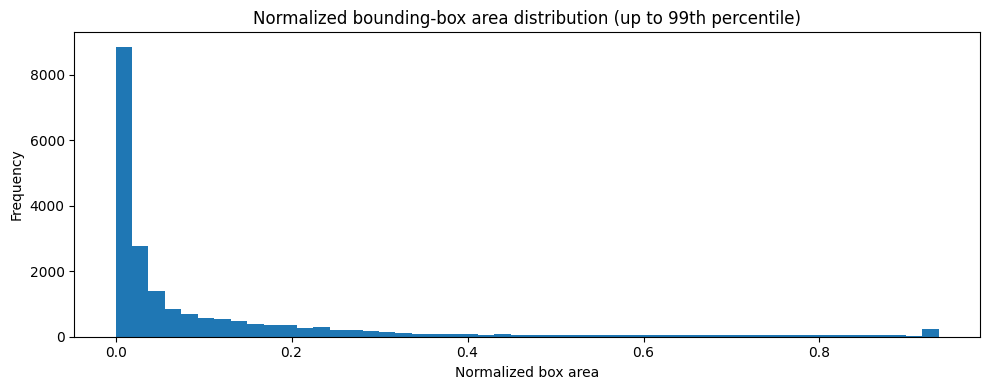

,boxes,median_area,mean_area,median_aspect_ratio
class_name,,,,
pothole,8583,0.009297,0.067403,1.480000
alligator,5915,0.076132,0.165360,0.861789
longitudinal,2867,0.013709,0.024043,0.542553
crack,2115,0.102846,0.163173,1.213376
transverse,677,0.020105,0.057059,3.916667
block,438,0.761567,0.634527,1.014573
edge,22,0.033601,0.051268,0.967157


,boxes,median_area,mean_area,median_aspect_ratio
class_name,,,,
edge,22,0.033601,0.051268,0.967157


In [10]:
if boxes_df.empty:
    raise RuntimeError(
        "No valid bounding boxes were found."
    )

class_split_counts = pd.crosstab(
    boxes_df["class_name"],
    boxes_df["split"],
)

class_split_counts["total"] = (
    class_split_counts.sum(axis=1)
)

display(
    class_split_counts.sort_values(
        "total",
        ascending=False,
    )
)

ax = class_split_counts.drop(
    columns="total"
).plot(
    kind="bar",
    figsize=(13, 5),
)

ax.set_title(
    "Road-damage object count by class and split"
)
ax.set_xlabel("Class")
ax.set_ylabel("Bounding boxes")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(
    AUDIT_DIR / "class_distribution.png",
    dpi=180,
)
plt.show()

clipped_area = boxes_df["area"].clip(
    upper=boxes_df["area"].quantile(0.99)
)

ax = clipped_area.plot(
    kind="hist",
    bins=50,
    figsize=(10, 4),
)

ax.set_title(
    "Normalized bounding-box area distribution "
    "(up to 99th percentile)"
)
ax.set_xlabel("Normalized box area")
plt.tight_layout()
plt.savefig(
    AUDIT_DIR / "box_area_distribution.png",
    dpi=180,
)
plt.show()

class_statistics = (
    boxes_df.groupby("class_name")
    .agg(
        boxes=("class_name", "size"),
        median_area=("area", "median"),
        mean_area=("area", "mean"),
        median_aspect_ratio=(
            "aspect_ratio",
            "median",
        ),
    )
    .sort_values("boxes", ascending=False)
)

display(class_statistics)

rare_classes = class_statistics[
    class_statistics["boxes"] < 100
]

if not rare_classes.empty:
    print(
        "WARNING: Classes with fewer than 100 boxes:"
    )
    display(rare_classes)

## 9. Inspect random converted bounding boxes

Review these images carefully, especially thin cracks and the annotations originally stored as polygons.

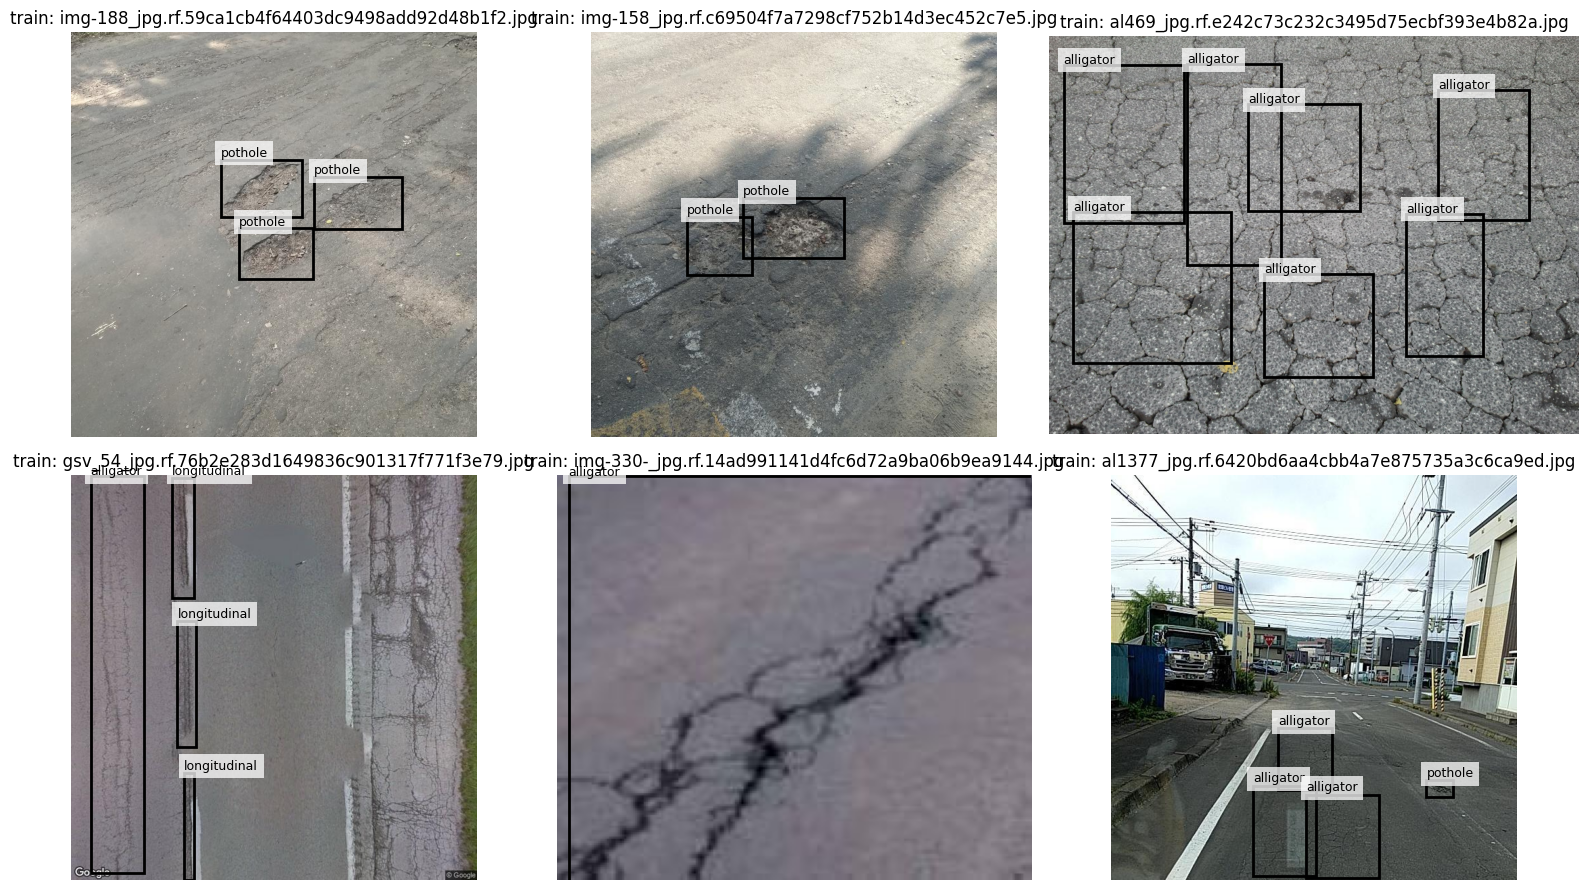

In [11]:
def read_detection_labels(label_path: Path):
    rows = []

    if not label_path.exists():
        return rows

    for line in label_path.read_text(
        encoding="utf-8"
    ).splitlines():
        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id = int(float(parts[0]))
        x_center, y_center, width, height = map(
            float,
            parts[1:],
        )

        rows.append(
            (
                class_id,
                x_center,
                y_center,
                width,
                height,
            )
        )

    return rows

def show_annotated_samples(
    split: str = "train",
    count: int = 6,
    seed: int = SEED,
):
    subset = images_df[
        (images_df["split"] == split)
        & (images_df["image_valid"])
        & (images_df["objects"] > 0)
    ]

    if subset.empty:
        print("No annotated samples found.")
        return

    sampled = subset.sample(
        min(count, len(subset)),
        random_state=seed,
    )

    columns = 3
    rows = int(np.ceil(len(sampled) / columns))

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(16, rows * 4.5),
    )

    axes = np.atleast_1d(axes).ravel()

    for axis, (_, row) in zip(
        axes,
        sampled.iterrows(),
    ):
        image_path = Path(row["image"])
        label_path = Path(row["label"])

        image = ImageOps.exif_transpose(
            Image.open(image_path)
        ).convert("RGB")

        width_px, height_px = image.size
        axis.imshow(image)

        for (
            class_id,
            x_center,
            y_center,
            width,
            height,
        ) in read_detection_labels(label_path):
            x_min = (
                x_center - width / 2
            ) * width_px

            y_min = (
                y_center - height / 2
            ) * height_px

            rectangle = patches.Rectangle(
                (x_min, y_min),
                width * width_px,
                height * height_px,
                fill=False,
                linewidth=2,
            )

            axis.add_patch(rectangle)

            axis.text(
                x_min,
                max(0, y_min - 5),
                class_names.get(
                    class_id,
                    str(class_id),
                ),
                fontsize=9,
                bbox={
                    "facecolor": "white",
                    "alpha": 0.75,
                    "edgecolor": "none",
                },
            )

        axis.set_title(
            f"{split}: {image_path.name}"
        )
        axis.axis("off")

    for axis in axes[len(sampled):]:
        axis.axis("off")

    plt.tight_layout()
    plt.savefig(
        AUDIT_DIR
        / f"{split}_annotated_samples.png",
        dpi=160,
    )
    plt.show()

show_annotated_samples(
    split="train",
    count=6,
)

## 10. Persist the processed dataset

In [12]:
OVERWRITE_PERSISTENT_PROCESSED_DATASET = True

if (
    PERSISTENT_DATASET_DIR.exists()
    and OVERWRITE_PERSISTENT_PROCESSED_DATASET
):
    print(
        "Removing previous processed dataset:",
        PERSISTENT_DATASET_DIR,
    )
    shutil.rmtree(PERSISTENT_DATASET_DIR)

if not PERSISTENT_DATASET_DIR.exists():
    print(
        "Copying processed dataset to Google Drive..."
    )
    shutil.copytree(
        LOCAL_DATASET_DIR,
        PERSISTENT_DATASET_DIR,
    )
else:
    print(
        "Processed dataset already exists:",
        PERSISTENT_DATASET_DIR,
    )

# Create a Drive-compatible YAML with a persistent path.
drive_yaml_path = (
    PERSISTENT_DATASET_DIR / "data_detection_drive.yaml"
)

drive_config = dict(canonical_config)
drive_config["path"] = str(
    PERSISTENT_DATASET_DIR.resolve()
)

with drive_yaml_path.open(
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        drive_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("Persistent processed dataset:")
print(PERSISTENT_DATASET_DIR)

print("\nPersistent YAML:")
print(drive_yaml_path.read_text())

Copying processed dataset to Google Drive...
Persistent processed dataset:
/content/drive/MyDrive/RoadDamageYOLO/data/road-damage-detection-bbox-v1

Persistent YAML:
path: /content/drive/MyDrive/RoadDamageYOLO/data/road-damage-detection-bbox-v1
train: train/images
val: valid/images
test: test/images
names:
- alligator
- block
- crack
- edge
- longitudinal
- pothole
- transverse



## 11. Save environment and handoff information

The training notebooks should use:

```python
PERSISTENT_DATASET_DIR = Path(
    "/content/drive/MyDrive/RoadDamageYOLO/data/"
    "road-damage-detection-bbox-v1"
)
```

They should copy that directory to local Colab storage before training.

In [13]:
PERSISTENT_DATASET_DIR = Path(
    "/content/drive/MyDrive/RoadDamageYOLO/data/"
    "road-damage-detection-bbox-v1"
)

In [14]:
environment = {
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "ultralytics": ultralytics.__version__,
}

(REPORTS_ROOT / "environment.json").write_text(
    json.dumps(
        environment,
        indent=2,
    ),
    encoding="utf-8",
)

handoff = {
    "persistent_dataset_dir": str(
        PERSISTENT_DATASET_DIR
    ),
    "persistent_data_yaml": str(
        drive_yaml_path
    ),
    "local_training_copy_recommended": (
        "/content/road-damage-detection-bbox-v1"
    ),
    "training_gate_passed": True,
    "processed_annotations": int(len(boxes_df)),
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
}

handoff_path = (
    PROJECT_ROOT / "dataset_handoff.json"
)

handoff_path.write_text(
    json.dumps(
        handoff,
        indent=2,
    ),
    encoding="utf-8",
)

print(json.dumps(handoff, indent=2))
print("\nDataset setup and audit completed successfully.")
print("Next notebook: 01_Train_YOLOv8s.ipynb")

{
  "persistent_dataset_dir": "/content/drive/MyDrive/RoadDamageYOLO/data/road-damage-detection-bbox-v1",
  "persistent_data_yaml": "/content/drive/MyDrive/RoadDamageYOLO/data/road-damage-detection-bbox-v1/data_detection_drive.yaml",
  "local_training_copy_recommended": "/content/road-damage-detection-bbox-v1",
  "training_gate_passed": true,
  "processed_annotations": 20617,
  "created_at_utc": "2026-07-11T16:07:00.365460+00:00"
}

Dataset setup and audit completed successfully.
Next notebook: 01_Train_YOLOv8s.ipynb
